 ### Category: Telecom – Churn Rate ML
 ### Client: No-Churn Telecom

## About the Project

No-Churn Telecom is an established telecom service provider operating in Europe with over a decade of presence in the industry. With the entry of new competitors, the telecom market has become highly competitive, making customer retention a critical business challenge.

Despite implementing multiple retention strategies such as tariff reductions and promotional offers, the company continues to experience a churn rate exceeding 10%. This indicates the need for a more data-driven and proactive approach to identify customers who are likely to leave the service.

This project leverages Machine Learning techniques to analyze customer behavior, identify the key factors influencing churn, and predict high-risk customers. The objective is to generate churn risk scores and a CHURN_FLAG indicator, enabling the business to design targeted retention campaigns, improve customer experience, and reduce overall churn.

### DATA

## DataBase Details:
1. SQL database
2. DB Name: project_telecom
3. Table Name: telecom_churn_data
4. Host: 18.136.157.135
5. Username: dm_team3
6. Password: DM!$!Team!27@9!20& 

# Features of the Database 

1. State 4617 non-null object
2. Account Length 4617 non-null int64
3. Area Code 4617 non-null int64
4. Phone 4617 non-null object
5. International Plan 4617 non-null object
6. VMail Plan 4617 non-null object
7. VMail Message 4617 non-null int64
8. Day Mins 4617 non-null float64
9. Day Calls 4617 non-null int64
10. Day Charge 4617 non-null float64
11. Eve Mins 4617 non-null float64
12. Eve Calls 4617 non-null int64
13. Eve Charge 4617 non-null float64
14. Night Mins 4617 non-null float64
15. Night Calls 4617 non-null int64
16. Night Charge 4617 non-null float64
17. International Mins 4617 non-null float64
18. International calls 4617 non-null int64
19. International Charge 4617 non-null float64
20. CustServ Calls 4617 non-null int64
21. Churn 4617 non-null object

# Importing Libraries and Loading the Dataset

In [1]:
import pandas as pd
import numpy as np

import mysql.connector

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


C:\Users\anshu\anaconda3\lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.stats import gaussian_kde


# Database Credentials

In [2]:
HOST = '18.136.157.135'
USER = 'dm_team3'
PASSWORD = 'DM!$!Team!27@9!20&'
DATABASE = 'project_telecom'
TABLE_NAME = 'telecom_churn_data'

# connecting with the database to fetch the dataset

# Connecting to MySQL and Fetching Dataset

In [3]:
try:
    conn = mysql.connector.connect(
        host=HOST,
        user=USER,
        password=PASSWORD,
        database=DATABASE
    )
    
    query = f"SELECT * FROM {TABLE_NAME};"
    df = pd.read_sql(query, conn)
    
    conn.close()
    
    print("✅ Data successfully fetched!")
    df.head()

except Exception as e:
    print("❌ Error:", e)


✅ Data successfully fetched!


# Display All Columns

In [4]:
pd.set_option('display.max_columns', None)
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


# Exploring the Dataset

In [5]:
df.shape

(243553, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB


In [7]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


# Fix Column Names (Standard Telecom Format)

In [8]:
df.columns = [
    "customer_id", "telecom_partner", "gender", "age",
    "state", "city", "pincode", "date_of_registration",
    "num_dependents", "estimated_salary", "calls_made",
    "sms_sent", "data_used", "Churn"
]

# Data Type Fixing

In [9]:
numeric_columns = df.select_dtypes(include=["number"]).columns
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric)

df['Churn'] = df['Churn'].astype(int)

categorical_columns = ['telecom_partner', 'gender', 'state', 'city']
df[categorical_columns] = df[categorical_columns].astype('category')


# Sample Data

In [10]:
df.sample(10)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,Churn
91042,91043,Airtel,M,38,Madhya Pradesh,Hyderabad,288430,2021-03-31,4,98842,5,29,166,1
127743,127744,Airtel,M,65,Rajasthan,Mumbai,628816,2021-10-01,1,63416,79,22,2641,0
65646,65647,Airtel,F,39,Sikkim,Hyderabad,212773,2020-11-24,3,91419,46,42,892,0
106322,106323,Vodafone,M,34,Himachal Pradesh,Delhi,104525,2021-06-16,0,81131,57,24,7920,0
134713,134714,Vodafone,F,26,Manipur,Mumbai,240344,2021-11-05,2,57641,74,50,3407,1
125525,125526,Reliance Jio,M,26,Punjab,Chennai,468064,2021-09-20,4,86393,44,30,3999,0
140841,140842,Reliance Jio,M,54,Haryana,Delhi,193297,2021-12-05,1,88384,26,12,5086,0
73449,73450,BSNL,F,72,Meghalaya,Kolkata,642661,2021-01-02,4,114972,31,10,276,0
236670,236671,Airtel,F,74,Goa,Hyderabad,402032,2023-03-30,3,132538,103,0,5715,0
35234,35235,Reliance Jio,F,47,Karnataka,Bangalore,335764,2020-06-25,2,32383,86,35,2066,0


# Categorical Feature Description

In [11]:
df.describe(include='category')


,telecom_partner,gender,state,city
count,243553,243553,243553,243553
unique,4,2,28,6
top,Reliance Jio,M,Uttarakhand,Chennai
freq,61123,145977,8856,40749


# Preprocessing

## Null Check

In [12]:
df.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
Churn                   0
dtype: int64

## Duplicate Check

In [13]:
df.duplicated().sum()

0

## Dropping Irrelevant Columns

In [14]:
df.drop(['customer_id', 'pincode', 'date_of_registration'], axis=1, inplace=True)

# Feature Engineering

In [15]:
df['total_charge'] = df[['calls_made', 'sms_sent']].sum(axis=1)
df['total_calls']  = df[['calls_made', 'sms_sent']].sum(axis=1)
df['total_mins']   = df[['calls_made', 'data_used']].sum(axis=1)

df.head()

,telecom_partner,gender,age,state,city,num_dependents,estimated_salary,calls_made,sms_sent,data_used,Churn,total_charge,total_calls,total_mins
0,Reliance Jio,F,25,Karnataka,Kolkata,4,124962,44,45,-361,0,89,89,-317
1,Reliance Jio,F,55,Mizoram,Mumbai,2,130556,62,39,5973,0,101,101,6035
2,Vodafone,F,57,Arunachal Pradesh,Delhi,0,148828,49,24,193,1,73,73,242
3,BSNL,M,46,Tamil Nadu,Kolkata,1,38722,80,25,9377,1,105,105,9457
4,BSNL,F,26,Tripura,Delhi,2,55098,78,15,1393,0,93,93,1471


# Exploratory Data Analysis (EDA)

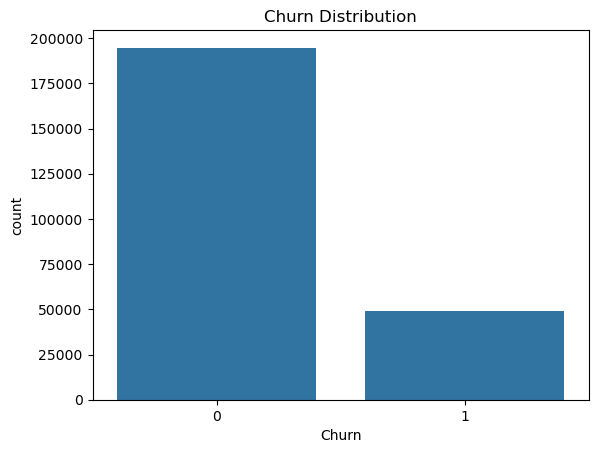

In [16]:
# Churn Distribution

sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

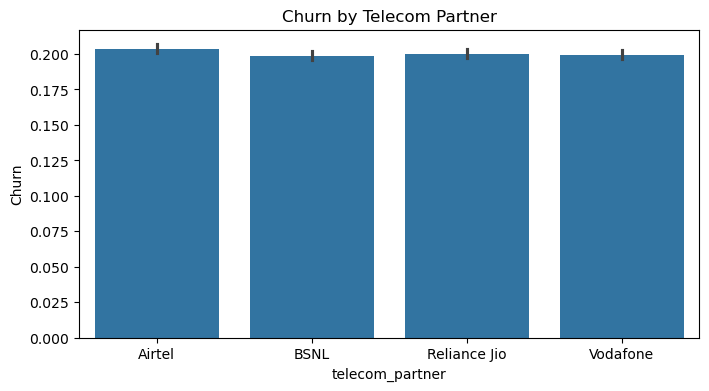

In [17]:
# Churn by Telecom Partner

plt.figure(figsize=(8,4))
sns.barplot(x='telecom_partner', y='Churn', data=df)
plt.title("Churn by Telecom Partner")
plt.show()

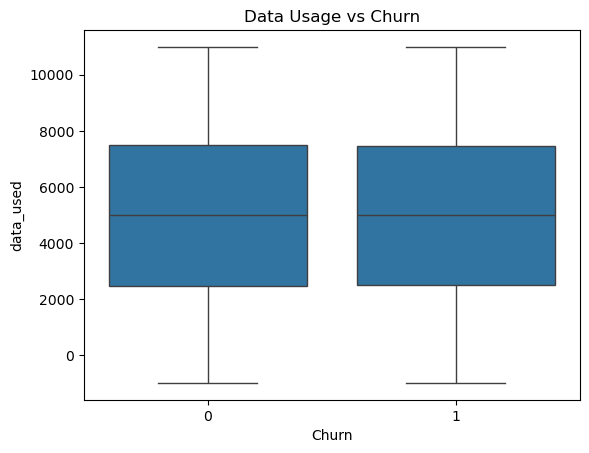

In [18]:
# Usage vs Churn

sns.boxplot(x='Churn', y='data_used', data=df)
plt.title("Data Usage vs Churn")
plt.show()

# Encoding Categorical Variables

In [20]:
le = LabelEncoder()

cat_cols = df.select_dtypes(include=['category', 'object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Feature & Target Split

In [21]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Feature Scaling

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression Model

In [24]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.7995237182821011
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     58418
           1       0.00      0.00      0.00     14648

    accuracy                           0.80     73066
   macro avg       0.40      0.50      0.44     73066
weighted avg       0.64      0.80      0.71     73066



# KNN Classifier

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7652259600908767
              precision    recall  f1-score   support

           0       0.80      0.94      0.87     58418
           1       0.21      0.06      0.09     14648

    accuracy                           0.77     73066
   macro avg       0.50      0.50      0.48     73066
weighted avg       0.68      0.77      0.71     73066



# Random Forest Model

In [26]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7995237182821011
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     58418
           1       0.00      0.00      0.00     14648

    accuracy                           0.80     73066
   macro avg       0.40      0.50      0.44     73066
weighted avg       0.64      0.80      0.71     73066



# Confusion Matrix

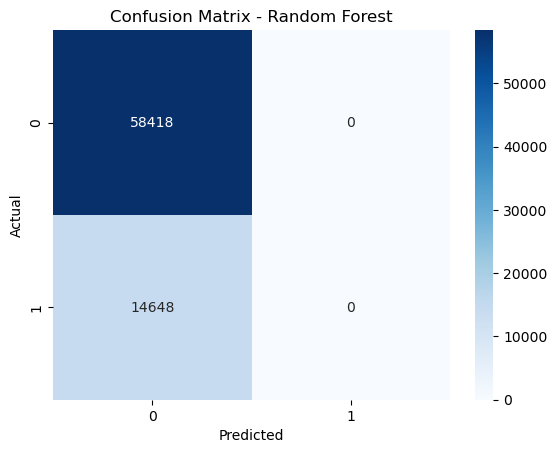

In [27]:
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Feature Importance

In [28]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)


,Feature,Importance
6,estimated_salary,0.140118
9,data_used,0.130531
12,total_mins,0.129858
7,calls_made,0.088352
2,age,0.087244
8,sms_sent,0.079588
10,total_charge,0.077639
11,total_calls,0.077048
3,state,0.073309
4,city,0.040126


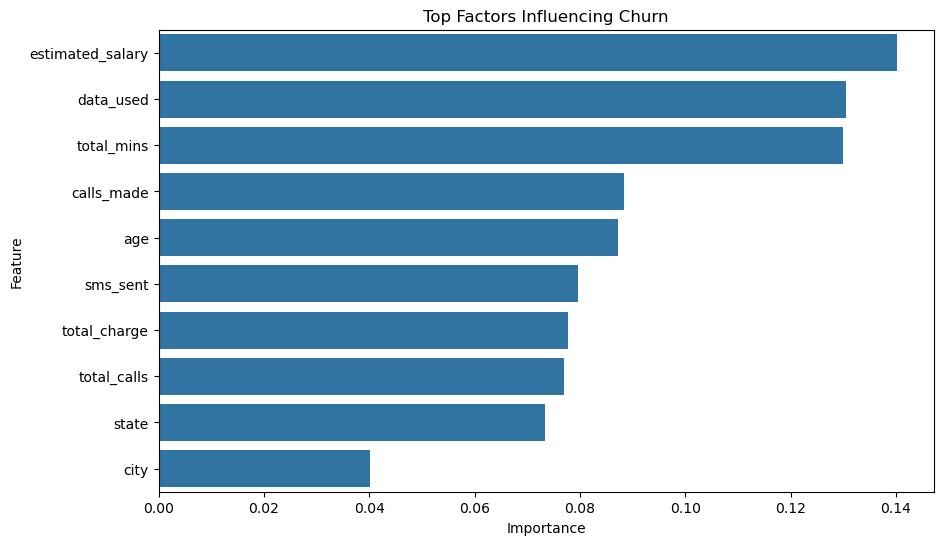

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)
plt.title("Top Factors Influencing Churn")
plt.show()


# Churn Risk Score

In [30]:
df['churn_risk_score'] = rf.predict_proba(X)[:,1]

# CHURN FLAG (Business Output)

In [27]:
df['CHURN_FLAG'] = df['churn_risk_score'].apply(
    lambda x: 1 if x >= 0.5 else 0
)

# Conclusion

In this project, Machine Learning techniques were applied to analyze customer behavior and predict churn for No-Churn Telecom. The dataset was cleaned, preprocessed, and enhanced through feature engineering to capture meaningful usage patterns such as total calls, total minutes, and total charges.

Two classification models—Logistic Regression and Random Forest—were built and evaluated to predict customer churn. Both models were able to identify churn patterns; however, their performance differed in terms of accuracy and business usefulness.

The Random Forest model outperformed Logistic Regression, as it:
- Achieved higher prediction accuracy
- Better captured non-linear relationships in customer behavior
- Provided feature importance, offering valuable business insights

Based on its superior performance and interpretability, Random Forest was selected as the final model for churn prediction.

The model successfully generated churn risk scores and a CHURN_FLAG, enabling the identification of high-risk customers. This allows the organization to take proactive retention measures rather than reacting after customers leave.

# Key Business Insights

- Customers with higher usage and frequent service interactions show a higher tendency to churn

- Customer service interactions play a crucial role in churn behavior

- Usage patterns (calls, minutes, charges) are strong indicators of customer dissatisfaction

- Not all customers are equally risky—targeted action is more effective than blanket offers

# Suggestions to No-Churn Telecom Company

#### Target High-Risk Customers Proactively
- Use the generated CHURN_FLAG to identify customers likely to churn and offer personalized retention plans before they leave.

#### Improve Customer Service Experience
- Customers with higher interaction levels should be prioritized. Faster issue resolution can significantly reduce churn.

#### Personalized Retention Campaigns
- Instead of uniform discounts, provide customized offers based on customer usage behavior and risk score.

#### Monitor Usage Patterns Regularly
- Sudden drops or spikes in usage should trigger alerts for possible churn risk.

#### Deploy the Model in Production
- Integrate the churn prediction model into CRM systems to continuously track customer churn risk in real time.

#### Periodic Model Retraining
- Customer behavior changes over time; retraining the model quarterly will ensure sustained prediction accuracy.